#**Grupo Individual - Matheus Lopes**
##**Informações:**
*   Email: 1666264@pucminas.edu.br

##**Descrições da Base Utilizada:**
O [dataset Default of Credit Card Clients](https://www.kaggle.com/datasets/narayanach/default-of-credit-card-clients), disponibilizado no Kaggle e originalmente proveniente do UCI Machine Learning Repository, contém informações de 30 mil clientes de cartão de crédito, incluindo características demográficas, limite de crédito, histórico de pagamentos, valores das faturas e pagamentos realizados nos meses anteriores. O principal objetivo da base é possibilitar a previsão de inadimplência no mês seguinte, tornando-a adequada para o desenvolvimento de um problema de classificação supervisionada. A variedade de variáveis financeiras e comportamentais também permite aplicar técnicas de análise exploratória, Feature Engineering, seleção de atributos, comparação de modelos de Machine Learning, otimização de hiperparâmetros e técnicas de interpretabilidade, como SHAP.








## **DESCRIÇÃO DO CANVAS: PROJETO FINAL – PIPELINE DE MACHINE LEARNING**
O Projeto Final consiste no desenvolvimento de um pipeline prático de Machine Learning de ponta a ponta (end-to-end),
aplicado a um problema real escolhido pelo próprio aluno. O objetivo é demonstrar domínio técnico e visão de negócio,
aplicando com rigor as melhores práticas discutidas ao longo da disciplina.
Cada aluno deverá escolher um problema real com um conjunto de dados real. A avaliação recai sobre o rigor metodológico
do pipeline — não sobre o dataset escolhido.
O aluno tem total liberdade para escolher o dataset e o problema de negócio. Datasets públicos de plataformas como
Kaggle, UCI ML Repository, Google Dataset Search ou dados reais do contexto profissional são bem-vindos.

## 2.2 Etapas Obrigatórias do Pipeline
O notebook deve implementar obrigatoriamente as seguintes etapas:
### Análise Exploratória de Dados (EDA)

*   Verificação de distribuições, detecção analítica/visual de outliers
*   Matriz de correlação e diagnóstico de dados ausentes
*   Uso de ferramentas automatizadas (ex: ydata-profiling) é incentivado

### Feature Engineering
*   Imputação de nulos com estratégia justificada
*   Tratamento de outliers (IQR, Winsorização ou transformação log)
*   Encodings adequados para alta e baixa cardinalidade
*   Criação de novas features com base em conhecimento de domínio
*   Transformações de escala quando necessárias


### Seleção de Features
*   Seleção rigorosa das variáveis preditoras utilizando Boruta (via BorutaPy) ou métodos equivalentes (SelectKBest, RFE,
SelectFromModel)

### Modelagem Baseline
*   Implementação de um estimador simples (Linear, Logístico ou Dummy) para fixar a métrica de referência

### Modelos de Alta Performance
*   Treinamento e avaliação comparativa de pelo menos 3 modelos
*   Recomendado: Random Forest, XGBoost, LightGBM e/ou CatBoost

### Tuning de Hiperparâmetros
*   Otimização dos parâmetros do melhor modelo usando RandomizedSearchCV, GridSearchCV ou Optuna

### Interpretabilidade (SHAP)
*   SHAP Summary Plot (importância global das features)
*   SHAP Waterfall ou Force Plot (análise local de uma amostra individual)

### IA Generativa como Ferramenta de Apoio
*   Uso de LLMs (ChatGPT, Copilot, etc.) para brainstorming de features, interpretação de métricas ou geração de código
*   Documentar os prompts utilizados e os resultados obtidos em células Markdown


## 3. DOCUMENTAÇÃO TÉCNICA DO PROJETO FINAL (10 pts)
Um relatório técnico em formato PDF, redigido com linguagem formal e padrão executivo. Esta documentação traduz o
esforço do notebook em um artefato de governança e estratégia de engenharia. Máximo de 8 páginas.

Seção Conteúdo Esperado
1. Visão Geral do Projeto Contextualização do problema, justificativa de negócio, objetivo técnico do algoritmo
(tipo de problema) e limitações de escopo

2. Arquitetura de Dados e
Engenharia
Mapeamento das fontes de dados, estratégias de Feature Engineering e tratamento
adotadas

3. Modelagem e Validação Justificativa da seleção de features, registro do desempenho de todos os modelos
testados, estratégia de validação cruzada

4. Interpretabilidade e
Resultados
Análise dos impactos de SHAP (Global e Local) traduzidos para linguagem de negócio

5. Conclusões e Próximos
Passos
Principais aprendizados, limitações do modelo e sugestões de melhorias futuras

#**1. Introdução**

* Problema de negócio
* Objetivo do projeto
* Variável target
* Hipótese

## **1.1 Importação da Base e Primeira Análise Exploratória**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


df = pd.read_excel(
    '/content/default of credit card clients.xls',
    header=1
)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [2]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

## **1.2 Contextualização do Projeto / Objetivo e Definição de Variáveis**

Em síntese temos a base de cartão de crédito de crédito, as caracteristicas dos clientes, seu histórico e valores das faturas e pagamentos realizados nos meses anteriores. O objetivo da base é possibilitar a previsão por meio das caracteristicas e descrições de cada cliente. Dessa forma estimando se teremos inadimplencia futura.

Abaixo segue um organograma de como funciona esse projeto!


                    DATASET
                       │
                       ▼
        ┌──────────────────────────┐
        │       Características    │
        │                          │
        │ LIMIT_BAL                │
        │ SEX                      │
        │ EDUCATION                │
        │ MARRIAGE                 │
        │ AGE                      │
        │ Histórico PAY            │
        │ BILL_AMT                 │
        │ PAY_AMT                  |
        | (...)                    │
        └────────────┬─────────────┘
                     │
                     ▼
                  MODELO
                     │
                     ▼
       **default payment next month**
                     │
             ┌───────┴───────┐
             ▼               ▼
             0               1
      Não inadimplente    Inadimplente

In [3]:
target = 'default payment next month'

# Variável alvo
y = df[target]

# Variáveis preditoras
X = df.drop(columns=[target, 'ID'])

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (30000, 23)
Dimensão de y: (30000,)


# **2. ETA (Análise Exploratória)**
* Estrutura da base
* Distribuição da variável alvo
* Nulos e duplicidades
* Distribuições
* Outliers
* Correlações

## **2.1 Estrutura da Base**

In [4]:
print(f"Quantidade de linhas: {df.shape[0]:,}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 30,000
Quantidade de colunas: 25


## **2.2 Distribuição da Variável Alvo**

In [5]:
# Distribuição da variável alvo
print(y.value_counts())

# Proporção entre 0 e 1 (0 = Não inadimplente | 1 = Inadimplente)
print("\nProporção:")
print(y.value_counts(normalize=True).round(4))

default payment next month
0    23364
1     6636
Name: count, dtype: int64

Proporção:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


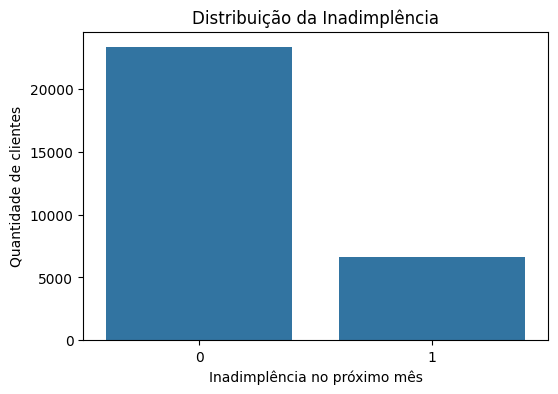

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribuição da Inadimplência')
plt.xlabel('Inadimplência no próximo mês')
plt.ylabel('Quantidade de clientes')
plt.show()

## **2.3 Descrição da Base**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## **2.4 Verificação de Dados Nulos / NaN e Duplicados**

In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum().sort_values(ascending=False)

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


## **2.5 Outliers**

In [12]:
# Variáveis numéricas contínuas
variaveis_numericas = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6',
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6'
]

# Cálculo dos limites pelo método IQR
outliers_resumo = []

In [13]:
for coluna in variaveis_numericas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    quantidade_outliers = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ).sum()

    percentual = quantidade_outliers / len(df) * 100

    outliers_resumo.append({
        'Variável': coluna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior,
        'Qtd. Outliers': quantidade_outliers,
        '% Outliers': percentual
    })

In [14]:
outliers_df = pd.DataFrame(outliers_resumo)
outliers_df.sort_values(
    by='% Outliers',
    ascending=False
)

,Variável,Q1,Q3,IQR,Limite Inferior,Limite Superior,Qtd. Outliers,% Outliers
11,PAY_AMT4,296.00,4013.25,3717.25,-5279.875,9589.125,2994,9.980000
13,PAY_AMT6,117.75,4000.00,3882.25,-5705.625,9823.375,2958,9.860000
12,PAY_AMT5,252.50,4031.50,3779.00,-5416.000,9700.000,2945,9.816667
8,PAY_AMT1,1000.00,5006.00,4006.00,-5009.000,11015.000,2745,9.150000
6,BILL_AMT5,1763.00,50190.50,48427.50,-70878.250,122831.750,2725,9.083333
9,PAY_AMT2,833.00,5000.00,4167.00,-5417.500,11250.500,2714,9.046667
7,BILL_AMT6,1256.00,49198.25,47942.25,-70657.375,121111.625,2693,8.976667
5,BILL_AMT4,2326.75,54506.00,52179.25,-75942.125,132774.875,2622,8.740000
10,PAY_AMT3,390.00,4505.00,4115.00,-5782.500,10677.500,2598,8.660000
4,BILL_AMT3,2666.25,60164.75,57498.50,-83581.500,146412.500,2469,8.230000


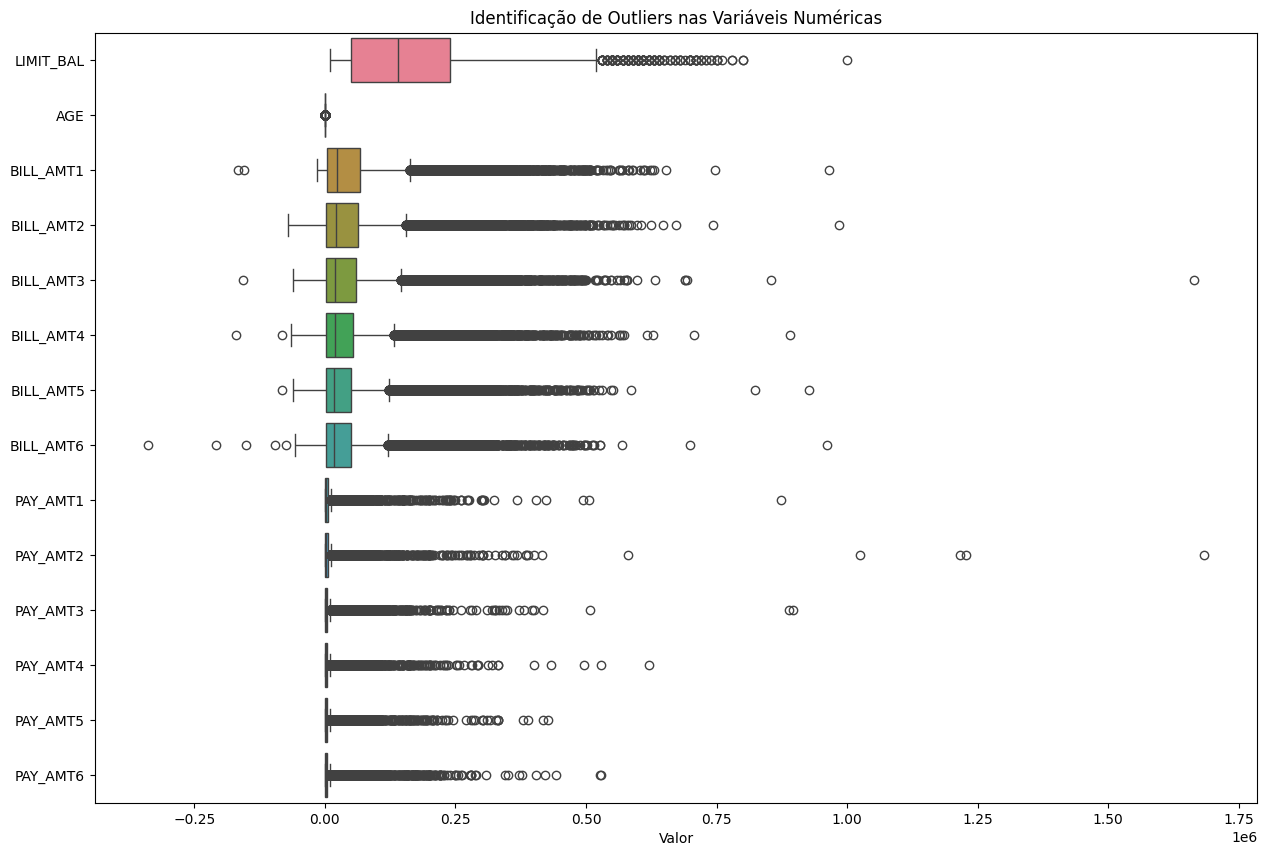

In [15]:
plt.figure(figsize=(15, 10))

sns.boxplot(
    data=df[variaveis_numericas],
    orient='h'
)

plt.title('Identificação de Outliers nas Variáveis Numéricas')
plt.xlabel('Valor')
plt.show()

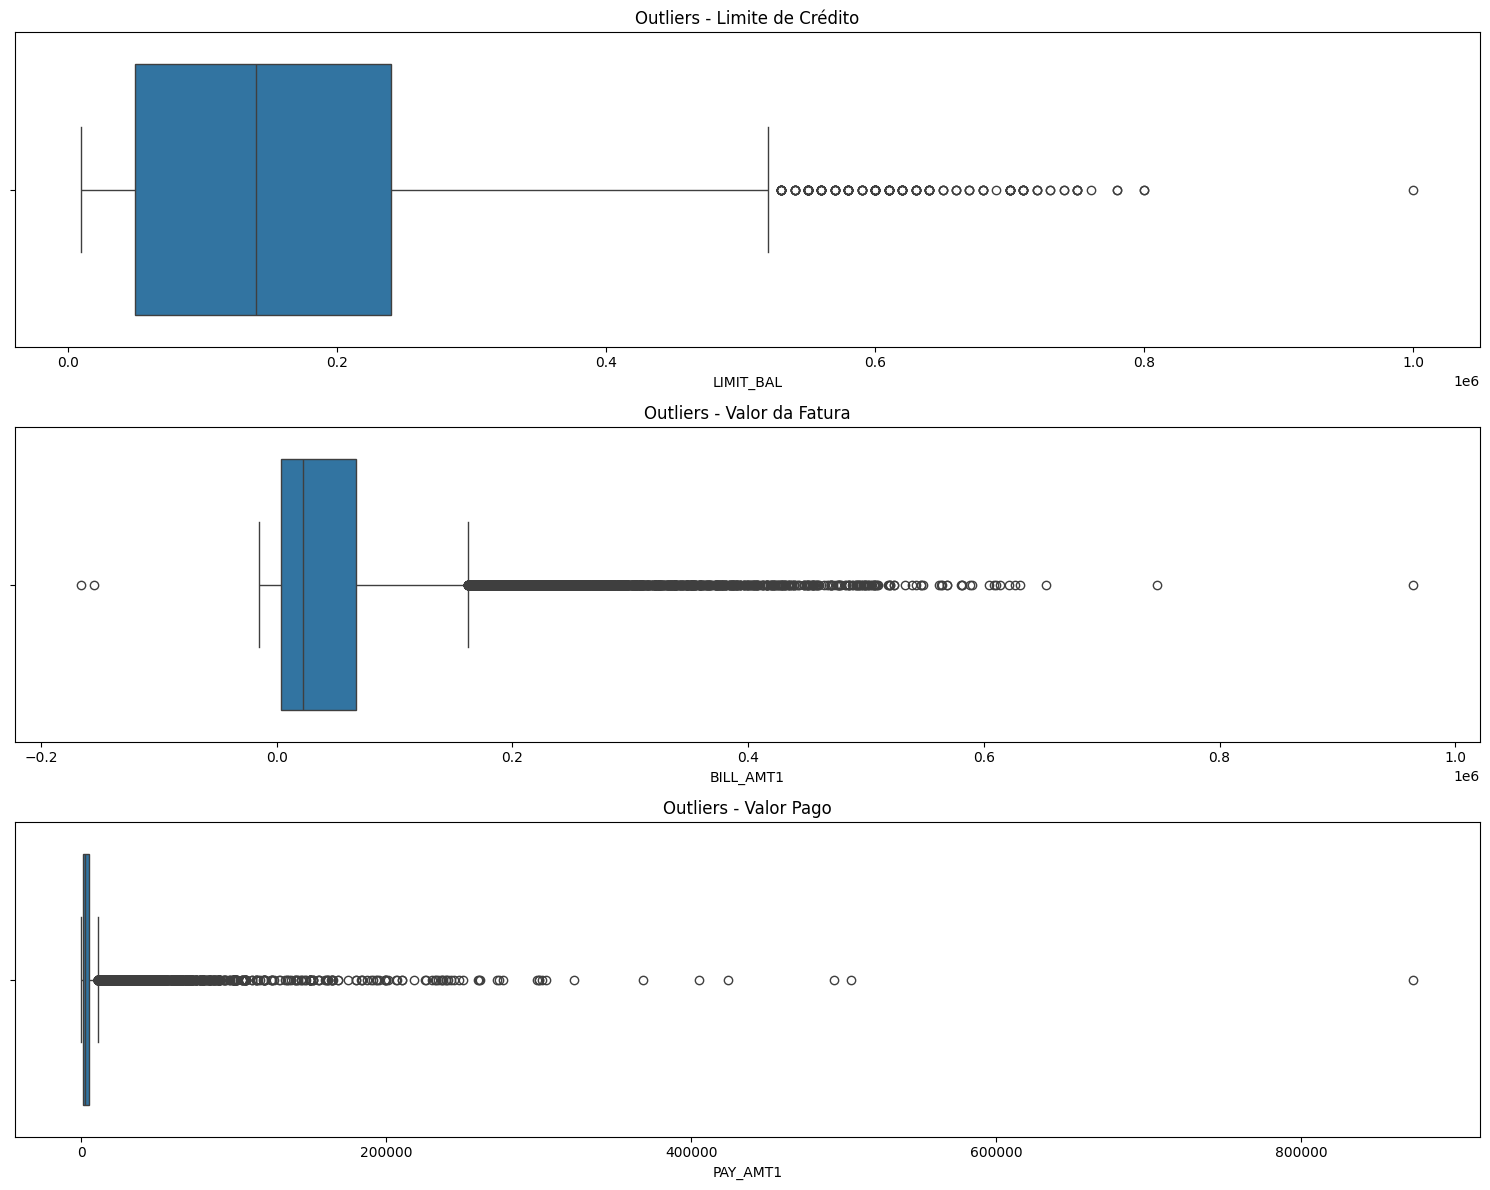

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

sns.boxplot(x=df['LIMIT_BAL'], ax=axes[0])
axes[0].set_title('Outliers - Limite de Crédito')

sns.boxplot(x=df['BILL_AMT1'], ax=axes[1])
axes[1].set_title('Outliers - Valor da Fatura')

sns.boxplot(x=df['PAY_AMT1'], ax=axes[2])
axes[2].set_title('Outliers - Valor Pago')

plt.tight_layout()
plt.show()

### **2.5.1 Conclusão Outliers**
Os outliers foram identificados utilizando o método do Intervalo Interquartil (IQR). Entretanto, devido à natureza financeira, **valores extremos não foram automaticamente removidos**, uma vez que podem **representar comportamentos legítimos dos clientes**. A **influência dessas observações será avaliada durante a etapa de Feature Engineering e modelagem**.

Foi **identificando maior concentração de valores extremos nas variáveis relacionadas aos valores das faturas e pagamentos** realizados. As variáveis **PAY_AMT apresentaram aproximadamente 9% a 10%** de observações classificadas como outliers, enquanto as variáveis **BILL_AMT apresentaram percentuais entre 8% e 9%**. Entretanto, considerando a natureza financeira dos dados, esses valores não foram automaticamente removidos, pois podem representar comportamentos legítimos de clientes com maior capacidade de pagamento ou maior exposição financeira. **Como estratégia de tratamento, será avaliada a aplicação de transformações logarítmicas e a criação de variáveis agregadas, preservando a informação original e reduzindo a influência desproporcional de valores extremos sobre os modelos**.

## **2.6 Análise da Variável Alvo**

In [17]:
categoricas = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

for coluna in categoricas:
    print(f"Coluna: {coluna}\n")
    print(df[coluna].value_counts().sort_index())

Coluna: SEX

SEX
1    11888
2    18112
Name: count, dtype: int64
Coluna: EDUCATION

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
Coluna: MARRIAGE

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [18]:
for coluna in categoricas:
  pd.crosstab(
      df[coluna],
      df['default payment next month'],
      normalize='index'
  ) * 100
  print(df[categoricas].round(2))

       SEX  EDUCATION  MARRIAGE
0        2          2         1
1        2          2         2
2        2          2         2
3        2          2         1
4        1          2         1
...    ...        ...       ...
29995    1          3         1
29996    1          3         2
29997    1          2         2
29998    1          3         1
29999    1          2         1

[30000 rows x 3 columns]
       SEX  EDUCATION  MARRIAGE
0        2          2         1
1        2          2         2
2        2          2         2
3        2          2         1
4        1          2         1
...    ...        ...       ...
29995    1          3         1
29996    1          3         2
29997    1          2         2
29998    1          3         1
29999    1          2         1

[30000 rows x 3 columns]
       SEX  EDUCATION  MARRIAGE
0        2          2         1
1        2          2         2
2        2          2         2
3        2          2         1
4        1          

In [19]:
print(df[categoricas].describe().round(2))

            SEX  EDUCATION  MARRIAGE
count  30000.00   30000.00  30000.00
mean       1.60       1.85      1.55
std        0.49       0.79      0.52
min        1.00       0.00      0.00
25%        1.00       1.00      1.00
50%        2.00       2.00      2.00
75%        2.00       2.00      2.00
max        2.00       6.00      3.00


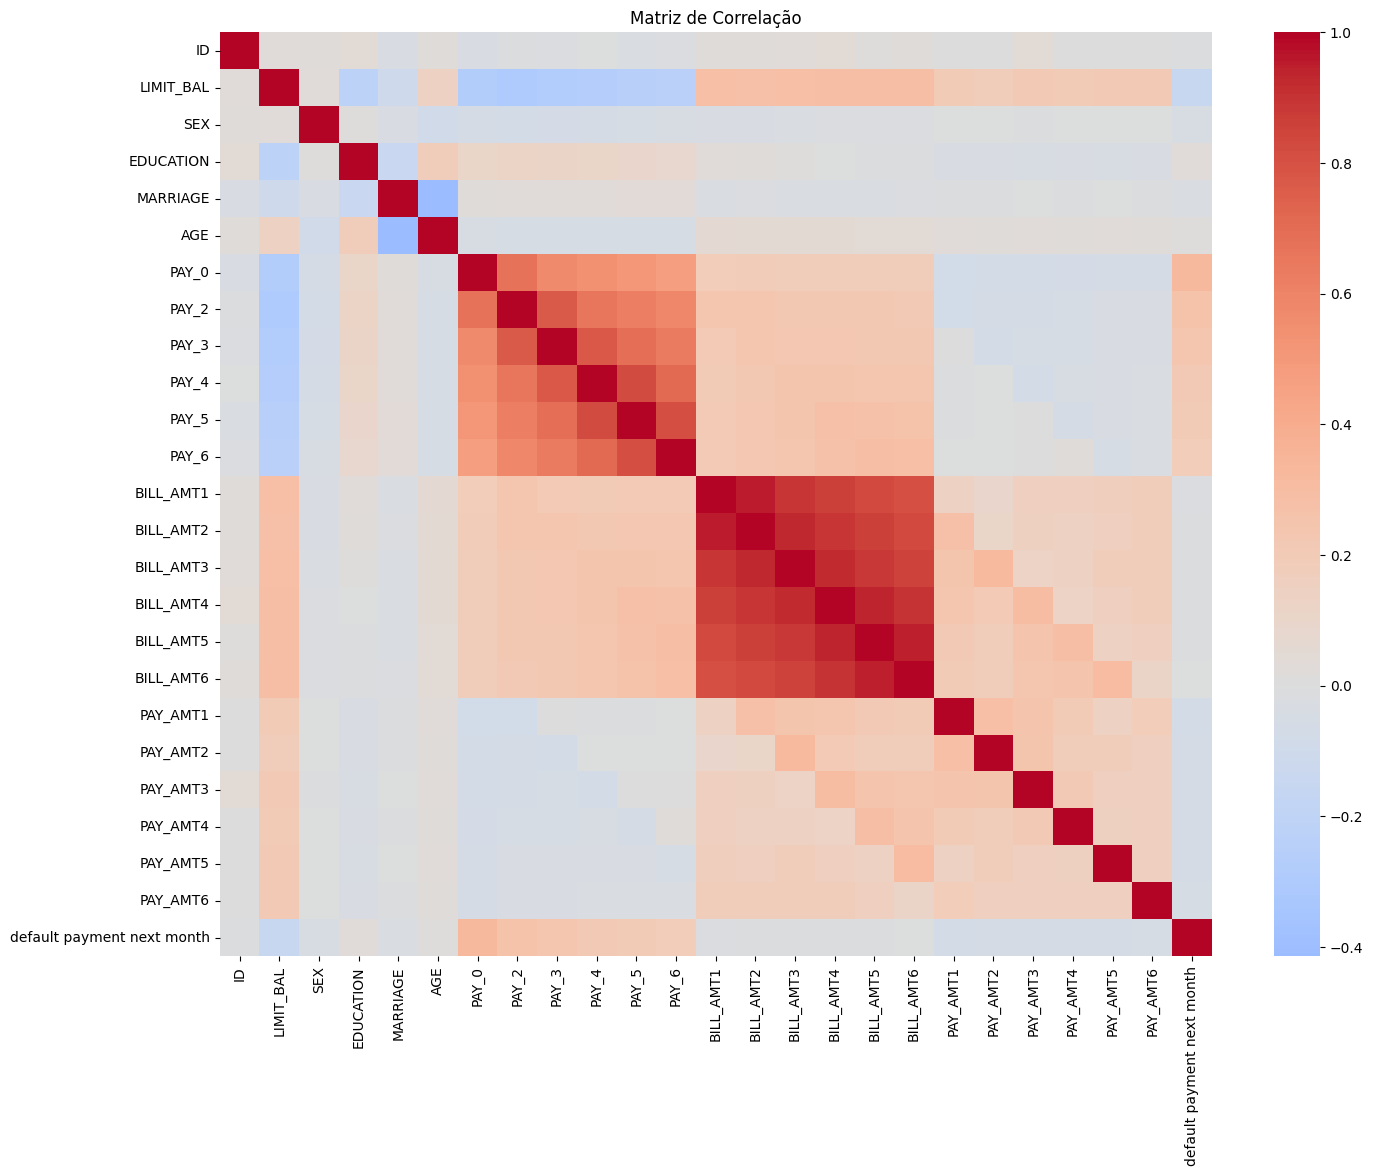

In [20]:
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de Correlação')
plt.show()

In [21]:
for coluna in categoricas:
    print(f'\n===== {coluna} =====')

    taxa_default = (
        df.groupby(coluna)['default payment next month']
        .mean()
        .mul(100)
        .round(2)
    )

    print(taxa_default)


===== SEX =====
SEX
1    24.17
2    20.78
Name: default payment next month, dtype: float64

===== EDUCATION =====
EDUCATION
0     0.00
1    19.23
2    23.73
3    25.16
4     5.69
5     6.43
6    15.69
Name: default payment next month, dtype: float64

===== MARRIAGE =====
MARRIAGE
0     9.26
1    23.47
2    20.93
3    26.01
Name: default payment next month, dtype: float64


### **2.6.1 Conclusão da Análise**
A análise das variáveis categóricas `SEX`, `EDUCATION` e `MARRIAGE` mostrou diferenças nas taxas de inadimplência entre os grupos:

A variável `SEX` apresentou taxas de 24,17% para a categoria 1 e 20,78% para a categoria 2, indicando uma diferença moderada.

Em `EDUCATION`, as categorias 2 e 3 apresentaram as maiores taxas de inadimplência entre os grupos mais representativos, com 23,73% e 25,16%, respectivamente. As categorias 0, 4, 5 e 6 apresentaram baixa frequência e taxas bastante distintas, indicando a necessidade de avaliar seu agrupamento como categorias de menor frequência ou “Outros”.

Para `MARRIAGE`, as categorias 1, 2 e 3 apresentaram taxas de 23,47%, 20,93% e 26,01%, respectivamente, enquanto a categoria 0 apresentou apenas 9,26% e possui baixa representatividade.

Dessa forma, as **variáveis apresentam potencial preditivo e serão mantidas para as próximas etapas**, com tratamento específico das categorias raras antes da modelagem.


#**3. Feature Engineering**

* Tratamento de nulos
* Tratamento de outliers
* Encoding
* Novas variáveis financeiras/comportamentais
* Escalonamento



### **3.1 Criação de Métricas para o Feature Selection**
A etapa de Feature Selection reduz o conjunto de variáveis disponíveis, mantendo apenas aquelas que apresentam maior relevância para a previsão do modelo. Exemplo Visual Abaixo:

```text
┌─────────────────────┐
│   40 FEATURES       │
│  Dados disponíveis  │
└──────────┬──────────┘
           │
           ▼
┌─────────────────────┐
│ FEATURE SELECTION   │
│   Boruta / RFE      │
└──────────┬──────────┘
           │
           ▼
┌─────────────────────┐
│   18 FEATURES       │
│    SELECIONADAS     │
└──────────┬──────────┘
           │
           ▼
┌─────────────────────┐
│       MODELO        │
│ Classificação       │
└─────────────────────┘

  ```text
                  FEATURES
                     │
        ┌────────────┼────────────┐
        │            │            │
        ▼            ▼            ▼
   LIMIT_BAL        AGE         PAY_0
        │            │            │
        ▼            ▼            ▼
    RELEVANTE    RELEVANTE    MUITO RELEVANTE

####**3.1.1 Métricas de Fatura**

In [22]:
# Média de Fatura
df['AVG_BILL_AMT'] = df[
    ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3','BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
].mean(axis=1)

# Max de Fatura
df['MAX_BILL_AMT'] = df[
    ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3','BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
].max(axis=1)

print(df[['AVG_BILL_AMT', 'MAX_BILL_AMT']].describe().round(2))

       AVG_BILL_AMT  MAX_BILL_AMT
count      30000.00      30000.00
mean       44976.95      60572.44
std        63260.72      78404.81
min       -56043.17      -6029.00
25%         4781.33      10060.00
50%        21051.83      31208.50
75%        57104.42      79599.00
max       877313.83    1664089.00


####**3.1.2 Métricas de Pagamento**

In [23]:
# Média sw Pagamento
df['AVG_PAY_AMT'] = df[
    ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
].mean(axis=1)

# Max de Pagamento
df['MAX_PAY_AMT'] = df[
    ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
].max(axis=1)

print(df[['AVG_PAY_AMT', 'MAX_PAY_AMT']].describe().round(2))

       AVG_PAY_AMT  MAX_PAY_AMT
count     30000.00     30000.00
mean       5275.23     15848.23
std       10137.95     37933.56
min           0.00         0.00
25%        1113.29      2198.00
50%        2397.17      5000.00
75%        5583.92     12100.00
max      627344.33   1684259.00


####**3.1.3 Capacidade de Pagamento**

In [24]:
# Relação entre pagamento e fatura
df['PAYMENT_RATIO'] = (
    df['AVG_PAY_AMT'] / df['AVG_BILL_AMT'].replace(0, np.nan)
)

df['PAYMENT_RATIO'] = df['PAYMENT_RATIO'].fillna(0)

print(df['PAYMENT_RATIO'].describe().round(4))

count    30000.0000
mean         0.3809
std          7.6710
min       -546.9286
25%          0.0410
50%          0.0849
75%          0.5869
max        797.0000
Name: PAYMENT_RATIO, dtype: float64


####**3.1.4 Utilização de Crédito**

In [25]:
df['CREDIT_UTILIZATION'] = (
    df['AVG_BILL_AMT'] / df['LIMIT_BAL'].replace(0, np.nan)
)

####**3.1.5 Quantidade de Mês sem Pagamento**

In [26]:
pay_cols = [
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

df['NUM_DELAYED_MONTHS'] = (
    df[pay_cols] > 0
).sum(axis=1)

In [27]:
df['MAX_PAYMENT_DELAY'] = df[pay_cols].max(axis=1)

#**4. Modelagem - Seleção do Modelo de Feature**
* BorutaPy ou método equivalente
* Comparação antes/depois da seleção

| Método                       | Como seleciona                                              | Vantagem                             | Desvantagem                                                   |
| ---------------------------- | ----------------------------------------------------------- | ------------------------------------ | ------------------------------------------------------------- |
| **Boruta / BorutaPy**        | Compara importância das features com variáveis “sombreadas” | Muito bom para justificar relevância | Mais pesado computacionalmente                                |
| **SelectKBest**              | Seleciona as K melhores pelo teste estatístico              | Simples e rápido                     | Pode ignorar interações entre variáveis                       |
| **RFE**                      | Remove iterativamente as menos importantes                  | Fácil de explicar                    | Pode ser lento                                                |
| **RFECV**                    | RFE + validação cruzada para escolher K                     | Mais rigoroso que RFE                | Mais processamento                                            |
| **SelectFromModel**          | Seleciona com base na importância de um modelo              | Muito prático                        | Depende do modelo escolhido                                   |
| **L1 / Lasso / Logistic L1** | Penalização elimina coeficientes                            | Excelente para modelos lineares      | Pode ter dificuldades com variáveis altamente correlacionadas |
| **Mutual Information**       | Mede dependência entre feature e target                     | Captura relações não lineares        | Não considera interação entre features                        |


In [28]:
target = 'default payment next month'

X = df.drop(columns=[target, 'ID'])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24000, 31)
X_test: (6000, 31)
y_train: (24000,)
y_test: (6000,)


In [29]:
print("Quantidade de features:", X.shape[1])

for i, coluna in enumerate(X.columns, start=1):
    print(f"{i:02d}. {coluna}")

Quantidade de features: 31
01. LIMIT_BAL
02. SEX
03. EDUCATION
04. MARRIAGE
05. AGE
06. PAY_0
07. PAY_2
08. PAY_3
09. PAY_4
10. PAY_5
11. PAY_6
12. BILL_AMT1
13. BILL_AMT2
14. BILL_AMT3
15. BILL_AMT4
16. BILL_AMT5
17. BILL_AMT6
18. PAY_AMT1
19. PAY_AMT2
20. PAY_AMT3
21. PAY_AMT4
22. PAY_AMT5
23. PAY_AMT6
24. AVG_BILL_AMT
25. MAX_BILL_AMT
26. AVG_PAY_AMT
27. MAX_PAY_AMT
28. PAYMENT_RATIO
29. CREDIT_UTILIZATION
30. NUM_DELAYED_MONTHS
31. MAX_PAYMENT_DELAY


### **4.1 BORUTA**
Compara importância das features com variáveis “sombreadas”

Exemplo:
```text
40 features
     ↓
Random Forest
     ↓
Boruta
     ↓
Features Confirmadas
     ↓
Modelagem

In [30]:
!pip install -q boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.9 MB/s eta 0:00:00


In [31]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Criação do Modelo Base
rf_boruta = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

In [32]:
boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    max_iter=50,
    random_state=42,
    verbose=2
)

boruta.fit(
    X_train.values,
    y_train.values
)

Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	5
Tentative: 	4
Rejected: 	22
Iteration: 	9 / 50
Confirmed: 	5
Tentative: 	4
Rejected: 	22
Iteration: 	10 / 50
Confirmed: 	5
Tentative: 	4
Rejected: 	22
Iteration: 	11 / 50
Confirmed: 	5
Tentative: 	4
Rejected: 	22
Iteration: 	12 / 50
Confirmed: 	5
Tentative: 	3
Rejected: 	23
Iteration: 	13 / 50
Confirmed: 	5
Tentative: 	3
Rejected: 	23
Iteration: 	14 / 50
Confirmed: 	5
Tentative: 	3
Rejected: 	23
Iteration: 	15 / 50
Confirmed: 	5
Tentative: 	3
Rejected: 	23
Iteration: 	16 / 50
Confirmed: 	6
Tentative: 	2
Rejected: 	23
Iteration: 	17 / 

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced',
                                          n_estimators=37, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x78EB0446FC40),
         max_iter=50, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x78EB0446FC40, verbose=2)

In [33]:
features_selecionadas = X_train.columns[boruta.support_]

print("Features selecionadas:")
for feature in features_selecionadas:
    print(feature)

print("\nQuantidade de features selecionadas:", len(features_selecionadas))

Features selecionadas:
PAY_0
AVG_PAY_AMT
PAYMENT_RATIO
CREDIT_UTILIZATION
NUM_DELAYED_MONTHS
MAX_PAYMENT_DELAY

Quantidade de features selecionadas: 6


In [34]:
ranking_boruta = pd.DataFrame({
    'Feature': X_train.columns,
    'Ranking': boruta.ranking_,
    'Selecionada': boruta.support_
}).sort_values('Ranking')

ranking_boruta

,Feature,Ranking,Selecionada
5,PAY_0,1,True
27,PAYMENT_RATIO,1,True
29,NUM_DELAYED_MONTHS,1,True
25,AVG_PAY_AMT,1,True
30,MAX_PAYMENT_DELAY,1,True
28,CREDIT_UTILIZATION,1,True
6,PAY_2,2,False
0,LIMIT_BAL,3,False
26,MAX_PAY_AMT,3,False
11,BILL_AMT1,5,False


### **4.2 SelectFromModel**

Exemplo:
```text
40 features
     ↓
Random Forest
     ↓
Importância das features
     ↓
Threshold
     ↓
Features selecionadas

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

In [36]:
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    estimator=rf_selector,
    threshold='median'
)

selector.fit(X_train, y_train)

SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced',
                                                 n_estimators=200, n_jobs=-1,
                                                 random_state=42),
                threshold='median')

In [37]:
features_selecionadas = X_train.columns[selector.get_support()]

print("Quantidade de features selecionadas:", len(features_selecionadas))
print("\nFeatures selecionadas:")

for feature in features_selecionadas:
    print(feature)

Quantidade de features selecionadas: 16

Features selecionadas:
LIMIT_BAL
AGE
PAY_0
BILL_AMT1
BILL_AMT2
BILL_AMT4
PAY_AMT2
PAY_AMT3
AVG_BILL_AMT
MAX_BILL_AMT
AVG_PAY_AMT
MAX_PAY_AMT
PAYMENT_RATIO
CREDIT_UTILIZATION
NUM_DELAYED_MONTHS
MAX_PAYMENT_DELAY


In [38]:
importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importância': selector.estimator_.feature_importances_,
    'Selecionada': selector.get_support()
})

importancias = importancias.sort_values(
    'Importância',
    ascending=False
)

importancias

,Feature,Importância,Selecionada
5,PAY_0,0.056113,True
30,MAX_PAYMENT_DELAY,0.051664,True
28,CREDIT_UTILIZATION,0.048732,True
4,AGE,0.048291,True
29,NUM_DELAYED_MONTHS,0.046290,True
0,LIMIT_BAL,0.044953,True
25,AVG_PAY_AMT,0.041770,True
27,PAYMENT_RATIO,0.041148,True
24,MAX_BILL_AMT,0.039136,True
26,MAX_PAY_AMT,0.038949,True


### **4.3 SelectKBest**
Para classificação, podemos usar mutual information, que consegue capturar relações não necessariamente lineares entre as features e o target.

In [39]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector_kbest = SelectKBest(
    score_func=mutual_info_classif,
    k=15
)

In [40]:
selector_kbest.fit(X_train, y_train)

SelectKBest(k=15, score_func=<function mutual_info_classif at 0x78eb04662020>)

In [41]:
features_kbest = X_train.columns[
    selector_kbest.get_support()
]

print("Quantidade de features selecionadas:", len(features_kbest))

print("\nFeatures selecionadas:")

for feature in features_kbest:
    print(feature)

Quantidade de features selecionadas: 15

Features selecionadas:
LIMIT_BAL
PAY_0
PAY_2
PAY_3
PAY_4
PAY_5
PAY_6
PAY_AMT1
PAY_AMT2
PAY_AMT3
AVG_PAY_AMT
MAX_PAY_AMT
CREDIT_UTILIZATION
NUM_DELAYED_MONTHS
MAX_PAYMENT_DELAY


In [42]:
resultado_kbest = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector_kbest.scores_,
    'Selecionada': selector_kbest.get_support()
})

resultado_kbest = resultado_kbest.sort_values(
    'Score',
    ascending=False
)

resultado_kbest

,Feature,Score,Selecionada
5,PAY_0,0.077130,True
29,NUM_DELAYED_MONTHS,0.076947,True
30,MAX_PAYMENT_DELAY,0.070013,True
6,PAY_2,0.048419,True
7,PAY_3,0.038297,True
8,PAY_4,0.029111,True
17,PAY_AMT1,0.027377,True
26,MAX_PAY_AMT,0.023686,True
9,PAY_5,0.022939,True
10,PAY_6,0.021973,True


###**4.4 Comparação**
Comparação dos métodos de Feature Selection

| Feature | Boruta | SelectFromModel | SelectKBest |
|:---|:---:|:---:|:---:|
| `LIMIT_BAL` | ❌ | ✅ | ✅ |
| `SEX` | ❌ | ❌ | ❌ |
| `EDUCATION` | ❌ | ❌ | ❌ |
| `MARRIAGE` | ❌ | ❌ | ❌ |
| `AGE` | ❌ | ✅ | ❌ |
| `PAY_0` | ✅ | ✅ | ✅ |
| `PAY_2` | ❌ | ❌ | ✅ |
| `PAY_3` | ❌ | ❌ | ✅ |
| `PAY_4` | ❌ | ❌ | ✅ |
| `PAY_5` | ❌ | ❌ | ✅ |
| `PAY_6` | ❌ | ❌ | ✅ |
| `BILL_AMT1` | ❌ | ✅ | ❌ |
| `BILL_AMT2` | ❌ | ✅ | ❌ |
| `BILL_AMT3` | ❌ | ❌ | ❌ |
| `BILL_AMT4` | ❌ | ✅ | ❌ |
| `BILL_AMT5` | ❌ | ❌ | ❌ |
| `BILL_AMT6` | ❌ | ❌ | ❌ |
| `PAY_AMT1` | ❌ | ❌ | ✅ |
| `PAY_AMT2` | ❌ | ✅ | ✅ |
| `PAY_AMT3` | ❌ | ✅ | ✅ |
| `PAY_AMT4` | ❌ | ❌ | ❌ |
| `PAY_AMT5` | ❌ | ❌ | ❌ |
| `PAY_AMT6` | ❌ | ❌ | ❌ |
| `AVG_BILL_AMT` | ❌ | ✅ | ❌ |
| `MAX_BILL_AMT` | ❌ | ✅ | ❌ |
| `AVG_PAY_AMT` | ✅ | ✅ | ✅ |
| `MAX_PAY_AMT` | ❌ | ✅ | ✅ |
| `PAYMENT_RATIO` | ✅ | ✅ | ❌ |
| `CREDIT_UTILIZATION` | ✅ | ✅ | ✅ |
| `NUM_DELAYED_MONTHS` | ✅ | ✅ | ✅ |
| `MAX_PAYMENT_DELAY` | ✅ | ✅ | ✅ |

Após a aplicação de três métodos de seleção de variáveis — Boruta, SelectFromModel e SelectKBest — optou-se pelo **Boruta como método principal para definição do conjunto de features utilizado na modelagem**. O Boruta apresentou um critério de seleção baseado na comparação da importância das variáveis originais com variáveis de referência aleatorizadas, permitindo identificar aquelas que apresentam evidência de relevância para a tarefa preditiva. Como resultado, foram selecionadas sete variáveis: `PAY_0`, `AVG_PAY_AMT`, `PAYMENT_RATIO`, `CREDIT_UTILIZATION`, `NUM_DELAYED_MONTHS` e `MAX_PAYMENT_DELAY`. A seleção também preserva features derivadas por conhecimento de domínio, especialmente relacionadas ao comportamento de pagamento, atrasos e utilização do crédito. As demais abordagens foram utilizadas como métodos complementares de comparação, mas não serão utilizadas para definir o conjunto final de variáveis nesta etapa.


In [43]:
comparacao = pd.DataFrame({
    'Feature': X_train.columns,
    'Boruta': boruta.support_,
    'SelectFromModel': selector.get_support(),
    'SelectKBest': selector_kbest.get_support()
})

comparacao

,Feature,Boruta,SelectFromModel,SelectKBest
0,LIMIT_BAL,False,True,True
1,SEX,False,False,False
2,EDUCATION,False,False,False
3,MARRIAGE,False,False,False
4,AGE,False,True,False
5,PAY_0,True,True,True
6,PAY_2,False,False,True
7,PAY_3,False,False,True
8,PAY_4,False,False,True
9,PAY_5,False,False,True


#**5. Avaliação da Modelagem**
Compare os modelos usando Cross-Validation e podemos usar um desses modelos

Modelos
* Baseline — Logistic Regression ou Dummy
* Random Forest
* XGBoost
* LightGBM
* CatBoost
---
Comparação:
* Precision
* Recall
* F1-Score
* ROC-AUC
* Matriz de confusão
* Cross-validation
---
Base Line:
* Dummy Baseline
* Regressão Logística
---


Na comparação inicial dos modelos, o CatBoost apresentou o maior valor de ROC-AUC (0,7796), seguido pelo LightGBM (0,7774) e Random Forest (0,7685). O LightGBM apresentou, por outro lado, o maior F1-Score (0,4745), enquanto o XGBoost apresentou o maior Recall (0,3709). Considerando o **ROC-AUC como métrica principal para a comparação inicial**, o **CatBoost foi definido como candidato principal para a etapa de otimização de hiperparâmetros**. Entretanto, **a escolha definitiva do modelo será realizada após o processo de tuning e posterior avaliação no conjunto de teste**.

Observando a etapa de Baseline, os resultados demonstraram que a **Regressão Logística apresentou desempenho superior ao Dummy Classifier**, alcançando ROC-AUC de 0,7412, contra 0,5000 do modelo de referência. Embora a Regressão Logística tenha apresentado Accuracy de 0,8090, seu Recall de 0,2793 evidencia limitações na identificação dos clientes que efetivamente apresentam inadimplência. O Dummy Classifier, por sua vez, obteve Accuracy de 0,7788, mas apresentou Recall, Precision e F1-Score iguais a zero, reforçando que a acurácia isoladamente pode ser inadequada para esse problema devido ao desbalanceamento das classes.

Dessa forma, a Regressão Logística foi definida como baseline supervisionado para comparação com os modelos mais complexos. A partir dessa referência, a etapa seguinte consiste em avaliar e otimizar modelos de ensemble e boosting, buscando verificar ganhos de desempenho na identificação do risco de inadimplência.



## **5.1 Estruturação da Modelagem e Comparação**

In [44]:
features_boruta = [
    'PAY_0',
    'AVG_PAY_AMT',
    'PAYMENT_RATIO',
    'CREDIT_UTILIZATION',
    'NUM_DELAYED_MONTHS',
    'MAX_PAYMENT_DELAY'
]

X_train_boruta = X_train[features_boruta]
X_test_boruta = X_test[features_boruta]

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, roc_auc_score, precision_score, recall_score, f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

In [46]:
!pip install -q catboost

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

modelos = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        random_state=42,
        verbosity=-1
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        random_state=42,
        verbose=False
    )
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [47]:
resultados = []

for nome, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X_train_boruta,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    resultados.append({
        'Modelo': nome,
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    })

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    'ROC-AUC',
    ascending=False
)

resultados_df

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1
4,CatBoost,0.775692,0.818667,0.667065,0.360710,0.468025
3,LightGBM,0.768691,0.818042,0.664712,0.358260,0.465447
2,XGBoost,0.746765,0.806833,0.608535,0.355435,0.448653
1,Random Forest,0.744258,0.799000,0.565682,0.395177,0.465233
0,Logistic Regression,0.741226,0.809000,0.662663,0.279340,0.392783


###**5.1.1 HyperParameter Tuning**
Hyperparameter Tuning do CatBoost, que foi o modelo selecionado na Cross-Validation.

A ideia é procurar automaticamente uma combinação de hiperparâmetros que melhore o ROC-AUC, sem utilizar o X_test.


In [48]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=False,
    thread_count=2
)

'''
 * iterations → quantidade de árvores/iterações;
 * depth → profundidade das árvores;
 * learning_rate → velocidade de aprendizado;
 * l2_leaf_reg → regularização;
 * border_count → quantidade de divisões utilizadas nas variáveis numéricas;
 * random_strength → aleatoriedade utilizada na seleção das divisões;
 * bagging_temperature → intensidade do bagging.
'''

param_grid = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [3, 5, 7]
}

In [49]:
random_search = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=param_grid,
    n_iter=8,
    scoring='roc_auc',
    cv=3, #cv=5 .... 5 folds caso temos memoria!
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(
    X_train_boruta,
    y_train
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=3,
                   estimator=CatBoostClassifier(random_state=42, thread_count=2, verbose=False),
                   n_iter=8, n_jobs=1,
                   param_distributions={'depth': [4, 6, 8],
                                        'iterations': [100, 200, 300],
                                        'l2_leaf_reg': [3, 5, 7],
                                        'learning_rate': [0.03, 0.05, 0.1]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [50]:
print("Melhores hiperparâmetros:")
print(random_search.best_params_)

Melhores hiperparâmetros:
{'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 200, 'depth': 8}


In [51]:
print("Melhor ROC-AUC:")
print(random_search.best_score_)

Melhor ROC-AUC:
0.7817442290756985


In [52]:
melhor_catboost = random_search.best_estimator_

##**5.2 BaseLine**

* Dummy Baseline
* Regressão Logística

In [53]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

dummy = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

scores_dummy = cross_validate(
    dummy,
    X_train_boruta,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_dummy = {
    'Modelo': 'Dummy Classifier',
    'ROC-AUC': scores_dummy['test_roc_auc'].mean(),
    'Accuracy': scores_dummy['test_accuracy'].mean(),
    'Precision': scores_dummy['test_precision'].mean(),
    'Recall': scores_dummy['test_recall'].mean(),
    'F1': scores_dummy['test_f1'].mean()
}

baseline_dummy

{'Modelo': 'Dummy Classifier',
 'ROC-AUC': np.float64(0.5),
 'Accuracy': np.float64(0.7787916666666667),
 'Precision': np.float64(0.0),
 'Recall': np.float64(0.0),
 'F1': np.float64(0.0)}

In [54]:
from sklearn.linear_model import LogisticRegression

logistic_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

scores_logistic = cross_validate(
    logistic_baseline,
    X_train_boruta,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_logistic = {
    'Modelo': 'Logistic Regression',
    'ROC-AUC': scores_logistic['test_roc_auc'].mean(),
    'Accuracy': scores_logistic['test_accuracy'].mean(),
    'Precision': scores_logistic['test_precision'].mean(),
    'Recall': scores_logistic['test_recall'].mean(),
    'F1': scores_logistic['test_f1'].mean()
}

baseline_logistic

{'Modelo': 'Logistic Regression',
 'ROC-AUC': np.float64(0.7412256840918643),
 'Accuracy': np.float64(0.8089999999999999),
 'Precision': np.float64(0.6626630825233331),
 'Recall': np.float64(0.2793404580477857),
 'F1': np.float64(0.3927832422065579)}

In [55]:
baseline_df = pd.DataFrame([
    baseline_dummy,
    baseline_logistic
])

baseline_df

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1
0,Dummy Classifier,0.500000,0.778792,0.000000,0.00000,0.000000
1,Logistic Regression,0.741226,0.809000,0.662663,0.27934,0.392783


###**5.2.1 Comparação BaseLine**

In [56]:
comparacao_final = pd.concat([baseline_df, resultados_df],
    ignore_index=True
)

comparacao_final.sort_values(
    'ROC-AUC',
    ascending=False
)

,Modelo,ROC-AUC,Accuracy,Precision,Recall,F1
2,CatBoost,0.775692,0.818667,0.667065,0.360710,0.468025
3,LightGBM,0.768691,0.818042,0.664712,0.358260,0.465447
4,XGBoost,0.746765,0.806833,0.608535,0.355435,0.448653
5,Random Forest,0.744258,0.799000,0.565682,0.395177,0.465233
1,Logistic Regression,0.741226,0.809000,0.662663,0.279340,0.392783
6,Logistic Regression,0.741226,0.809000,0.662663,0.279340,0.392783
0,Dummy Classifier,0.500000,0.778792,0.000000,0.000000,0.000000


#**6. Avaliação Final da Modelagem**

* Otimização do melhor modelo
* Comparação pré/pós-tuning

In [57]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Treinamento final
melhor_catboost.fit(
    X_train_boruta,
    y_train
)

# Predições
y_pred = melhor_catboost.predict(X_test_boruta)
y_prob = melhor_catboost.predict_proba(X_test_boruta)[:, 1]

# Métricas
roc_auc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ROC-AUC:", round(roc_auc, 4))
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))

ROC-AUC: 0.7767
Accuracy: 0.817
Precision: 0.6588
Recall: 0.358
F1-Score: 0.4639


In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



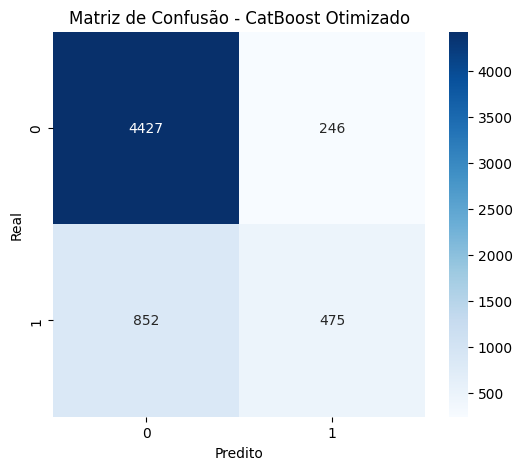

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão - CatBoost Otimizado')
plt.xlabel('Predito')
plt.ylabel('Real')

plt.show()

In [60]:
comparacao_tuning = pd.DataFrame({
    'Modelo': [
        'CatBoost antes do tuning',
        'CatBoost após o tuning'
    ],
    'ROC-AUC': [
        resultados_df.loc[
            resultados_df['Modelo'] == 'CatBoost',
            'ROC-AUC'
        ].iloc[0],
        random_search.best_score_
    ]
})

comparacao_tuning

,Modelo,ROC-AUC
0,CatBoost antes do tuning,0.775692
1,CatBoost após o tuning,0.781744


#**7. SHAP**

* Summary Plot
* Waterfall Plot
* Interpretação em linguagem de negócio

In [61]:
#!pip install -q shap

import shap
import matplotlib.pyplot as plt

melhor_modelo = random_search.best_estimator_

explainer = shap.Explainer(
    melhor_modelo,
    X_train_boruta
)

shap_values = explainer(X_test_boruta)


100%|===================| 5972/6000 [02:00<00:00]       

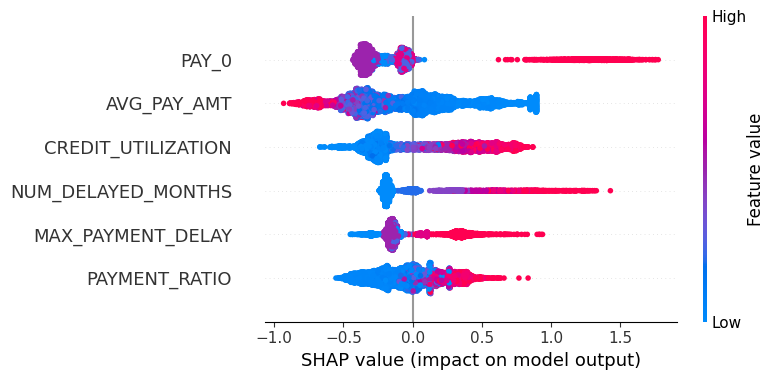

In [62]:
shap.summary_plot(
    shap_values,
    X_test_boruta
)

##**7.1 Summary**

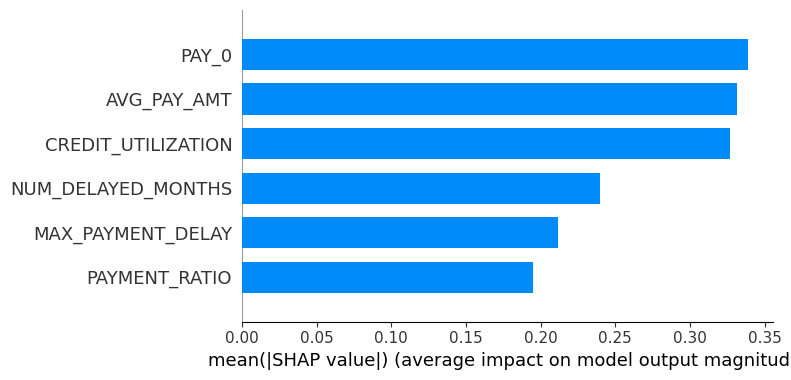

In [63]:
shap.summary_plot(
    shap_values,
    X_test_boruta,
    plot_type="bar"
)

A análise SHAP mostrou que **PAY_0, AVG_PAY_AMT e CREDIT_UTILIZATION** são as variáveis de maior influência nas previsões do CatBoost. Em seguida, destacam-se **NUM_DELAYED_MONTHS, MAX_PAYMENT_DELAY e PAYMENT_RATIO**. A direção desses efeitos é analisada no SHAP Summary Plot.


##**7.2 Walterfall**

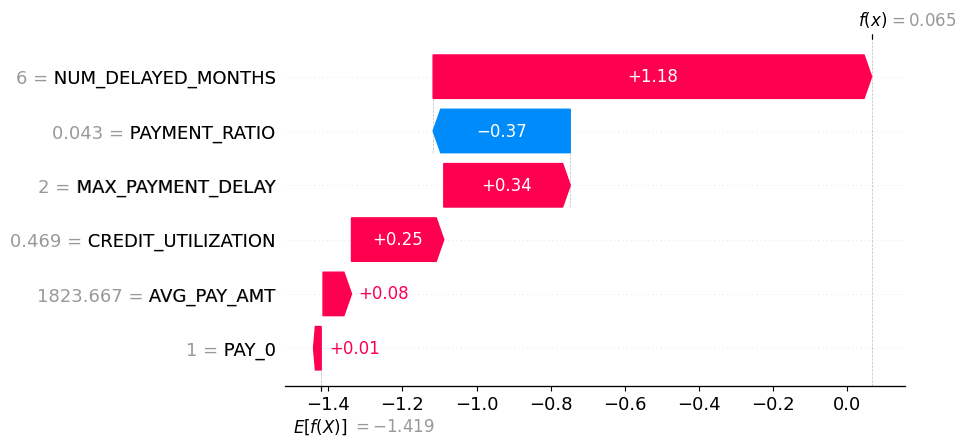

In [64]:
y_pred = melhor_modelo.predict(X_test_boruta)

indices_default = X_test_boruta.index[y_pred == 1]
indice_cliente = indices_default[0]
# y_test.loc[indice_cliente]

posicao = X_test_boruta.index.get_loc(indice_cliente)

shap.plots.waterfall(
    shap_values[posicao]
)

Para um cliente classificado como default, NUM_DELAYED_MONTHS = 6 foi o principal fator de aumento da previsão (+1,18), seguido por MAX_PAYMENT_DELAY = 2 (+0,34) e CREDIT_UTILIZATION = 0,469 (+0,25). AVG_PAY_AMT = 1.823,67 contribuiu com +0,08, enquanto PAYMENT_RATIO = 0,043 reduziu a previsão em −0,37. O PAY_0 = 1 teve impacto mínimo (+0,01), resultando em f(x) = 0,065.

1.  Número de meses com atraso (NUM_DELAYED_MONTHS) = 6 → contribuição de +1,18, principal fator de aumento da previsão.
2. Maior atraso no pagamento (MAX_PAYMENT_DELAY) = 2 → +0,34, aumentando a previsão.
3.  Utilização do crédito (CREDIT_UTILIZATION) = 0,469 → +0,25, contribuindo para maior risco previsto.
4.  Valor médio dos pagamentos (AVG_PAY_AMT) = 1.823,67 → +0,08, pequeno aumento.
5.  Status do pagamento mais recente (PAY_0) = 1 → +0,01, impacto praticamente neutro.
6.  Razão entre pagamentos e faturas (PAYMENT_RATIO) = 0,043 → −0,37, reduzindo a previsão.

##**7.3 Interpretação em linguagem de negócio**

O SHAP indica que PAY_0, AVG_PAY_AMT e CREDIT_UTILIZATION são as variáveis de maior influência global nas previsões do CatBoost. No Summary Plot, valores altos de PAY_0, CREDIT_UTILIZATION, NUM_DELAYED_MONTHS e MAX_PAYMENT_DELAY tendem a aumentar a saída do modelo, enquanto valores altos de AVG_PAY_AMT tendem a reduzi-la. Para o cliente analisado, NUM_DELAYED_MONTHS = 6 foi o principal fator de aumento (+1,18), seguido por MAX_PAYMENT_DELAY = 2 (+0,34) e CREDIT_UTILIZATION = 0,469 (+0,25). Já PAYMENT_RATIO = 0,043 reduziu a previsão (−0,37).

O resultado final do caso foi f(x) = 0,065, na escala de saída do modelo, correspondente a aproximadamente 51,6% quando convertido pela função logística. Assim, o SHAP permite explicar tanto quais variáveis mais influenciam o modelo globalmente quanto quais fatores determinaram uma previsão individual.

Um detalhe importante para o relatório, não há contradição entre:

* PAY_0 ser a variável mais importante globalmente;
* e NUM_DELAYED_MONTHS ser o maior fator no cliente específico.

O primeiro resultado vem do impacto médio no conjunto de teste; o segundo vem da explicação de uma única observação.